In [1]:
# Imports and Config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# ── Config ───────────────────────────────────────────────
INPUT_CSV    = 'Features_DroneRF_labeled.csv'
MODEL_OUT    = 'drone_xgb_model.pkl'
RANDOM_STATE = 42
N_FOLDS      = 5
# ─────────────────────────────────────────────────────────

print('All imports OK')

All imports OK


In [2]:
# Load Data
df = pd.read_csv(INPUT_CSV)

print(f'Shape       : {df.shape}')
print(f'Columns     : {df.columns.tolist()}')
print(f'\nLabel distribution:')
print(df['label'].value_counts().rename({1: 'Drone (1)', 0: 'No-Drone (0)'}))
print(f'\nAny NaNs : {df.isnull().sum().sum()}')
df.head()

Shape       : (454, 16)
Columns     : ['spectral_flatness', 'spectral_entropy', 'correlation_peak', 'power_variance', 'burst_count', 'burst_dur_mean_ms', 'burst_dur_std_ms', 'duty_cycle', 'micro_doppler_mean', 'micro_doppler_std', 'blade_rate_hz', 'doppler_mean_hz', 'doppler_std_hz', 'range_peak_bin', 'range_peak_power', 'label']

Label distribution:
label
Drone (1)       372
No-Drone (0)     82
Name: count, dtype: int64

Any NaNs : 0


,spectral_flatness,spectral_entropy,correlation_peak,power_variance,burst_count,burst_dur_mean_ms,burst_dur_std_ms,duty_cycle,micro_doppler_mean,micro_doppler_std,blade_rate_hz,doppler_mean_hz,doppler_std_hz,range_peak_bin,range_peak_power,label
0,0.102155,20.281940,0.057973,65.290924,3674,0.000050,0.000034,0.003667,9022.870117,8827.568359,200.320513,3218094.50,24667684.0,768.0,35.483654,1
1,0.047820,19.782911,0.057088,81.801384,3190,0.000055,0.000039,0.003518,7600.188477,919.042847,200.320513,2990981.75,24657836.0,768.0,34.430824,1
2,0.059773,19.855219,0.050938,66.137993,2667,0.000045,0.000031,0.002422,8788.822266,996.218750,200.320513,2909840.75,24659086.0,768.0,40.044685,1
3,0.094299,20.225368,0.211906,67.611298,3399,0.000056,0.000041,0.003780,7428.645508,241.087769,200.320513,2945644.25,24758214.0,768.0,34.531822,1
4,0.154180,20.617453,0.214907,50.612679,5625,0.000052,0.000036,0.005846,9647.363281,14705.422852,200.320513,2862308.25,24703740.0,768.0,29.658594,1


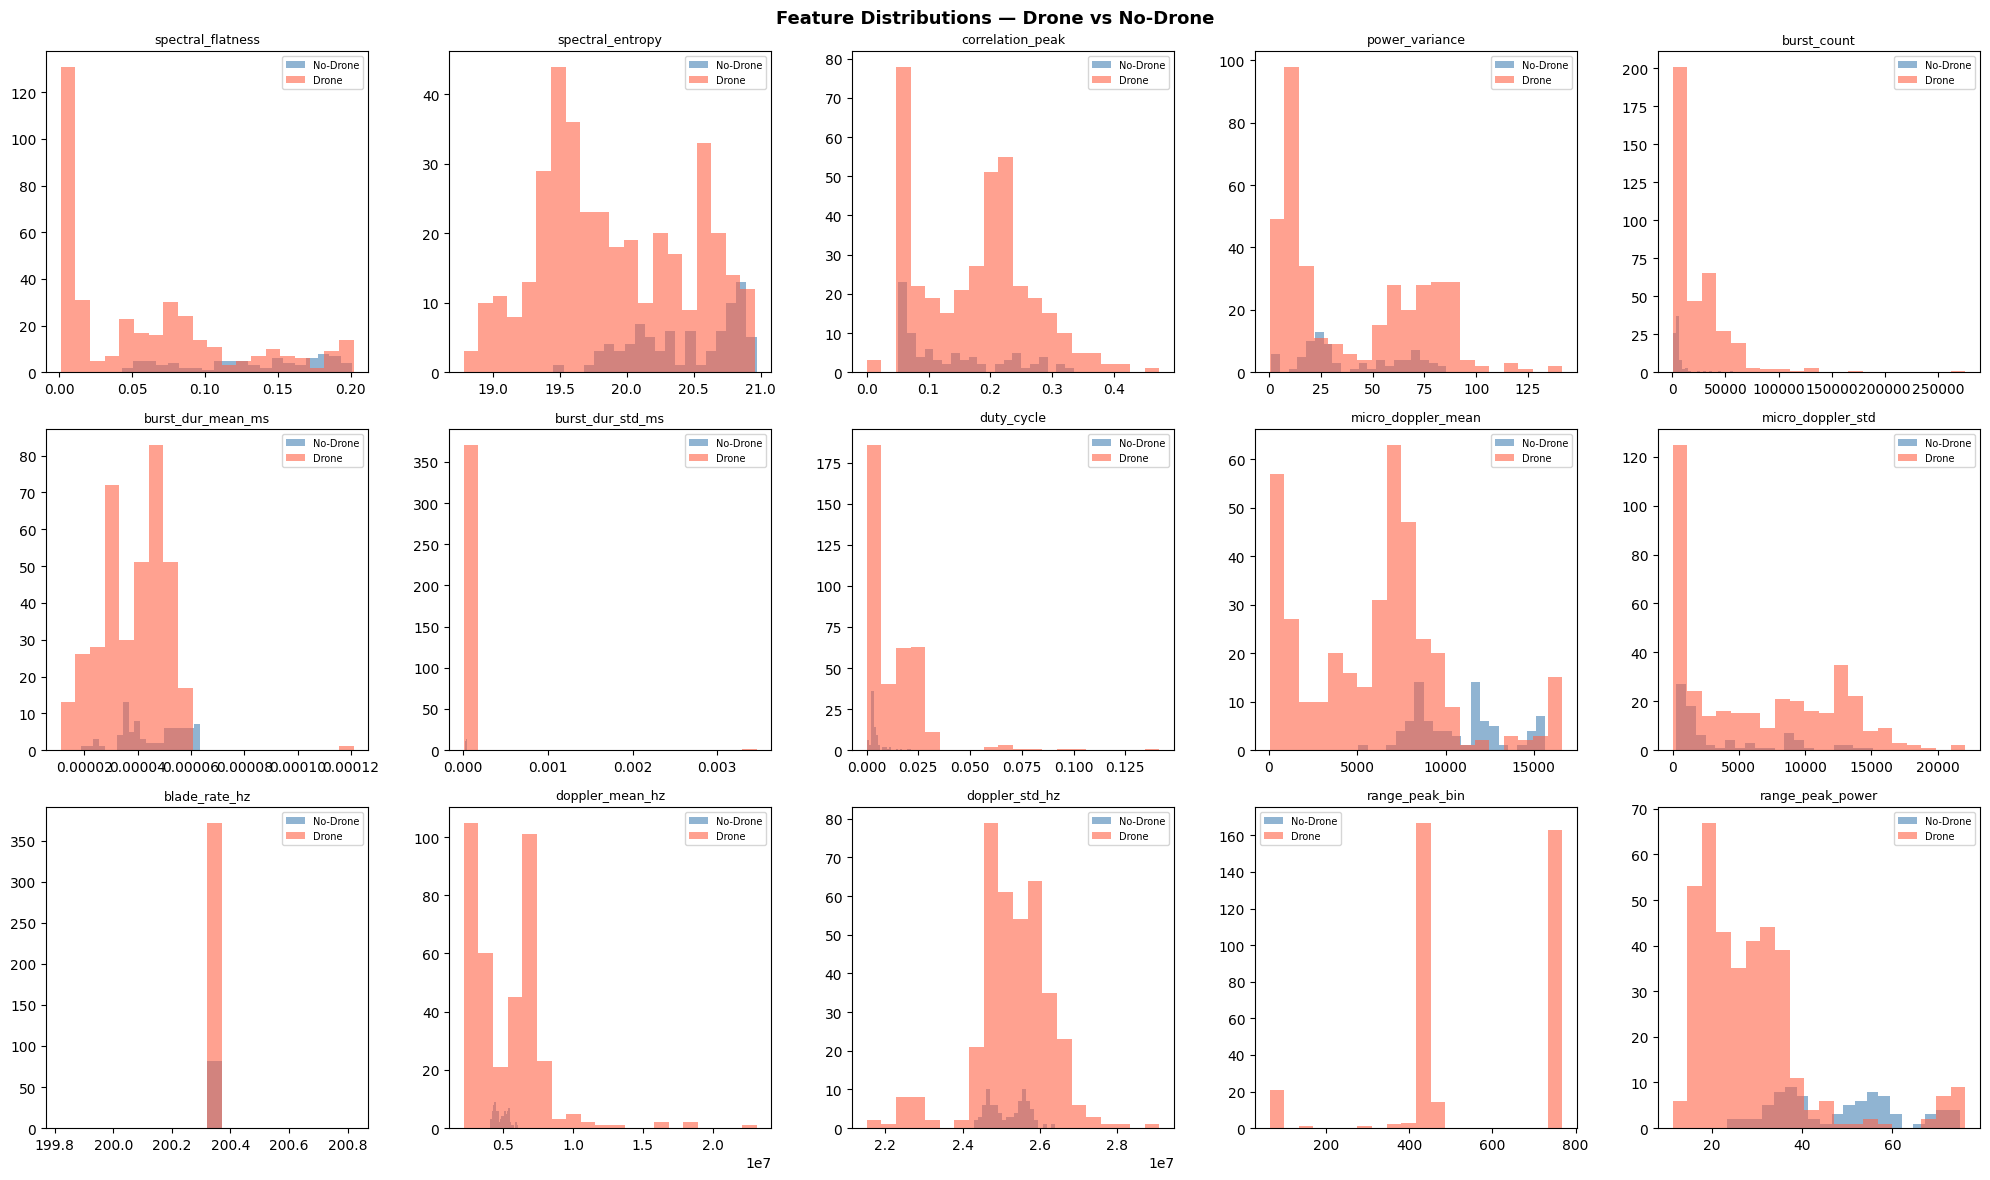

In [3]:
# Feature Distribution Plots
feature_cols = [c for c in df.columns if c != 'label']

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    for label, color, name in [(0, 'steelblue', 'No-Drone'), (1, 'tomato', 'Drone')]:
        axes[i].hist(
            df.loc[df['label'] == label, feat],
            bins=20, alpha=0.6, color=color, label=name
        )
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions — Drone vs No-Drone', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

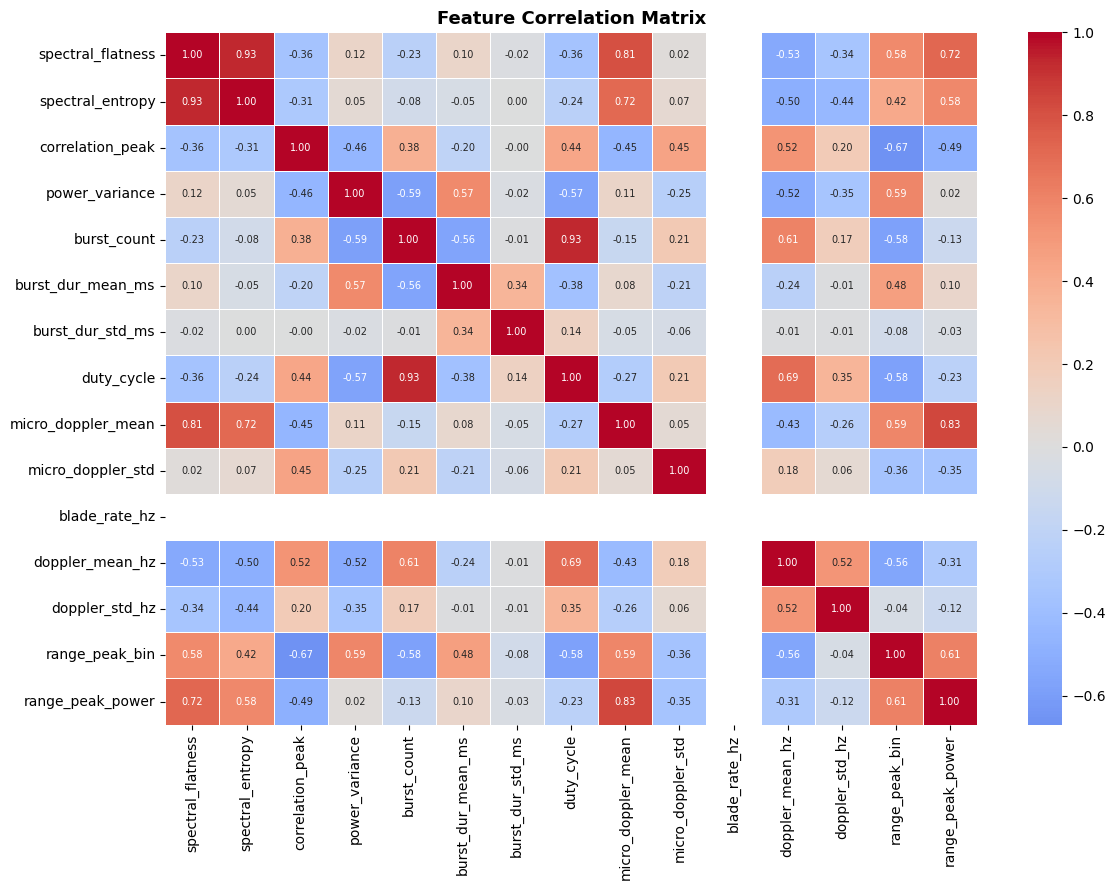

In [4]:
# Correlation Heatmap
plt.figure(figsize=(12, 9))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Prepare X, y
X = df[feature_cols].values
y = df['label'].values

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Class balance — Drone: {y.sum()}  No-Drone: {(y==0).sum()}')

X shape : (454, 15)
y shape : (454,)
Class balance — Drone: 372  No-Drone: 82


In [6]:
# Stratified K-Fold cross-validation
xgb_model = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'logloss',
    random_state     = RANDOM_STATE
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    xgb_model)
])

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(
    pipeline, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

print(f'\n{"="*50}')
print(f'{"Cross-Validation Results":^50}')
print(f'{"="*50}')
for metric in scoring:
    val = cv_results[f'test_{metric}']
    print(f'  {metric:<12}: {val.mean():.4f}  (±{val.std():.4f})')
print(f'{"="*50}')


             Cross-Validation Results             
  accuracy    : 0.9868  (±0.0108)
  precision   : 0.9868  (±0.0083)
  recall      : 0.9973  (±0.0053)
  f1          : 0.9920  (±0.0065)
  roc_auc     : 0.9922  (±0.0157)


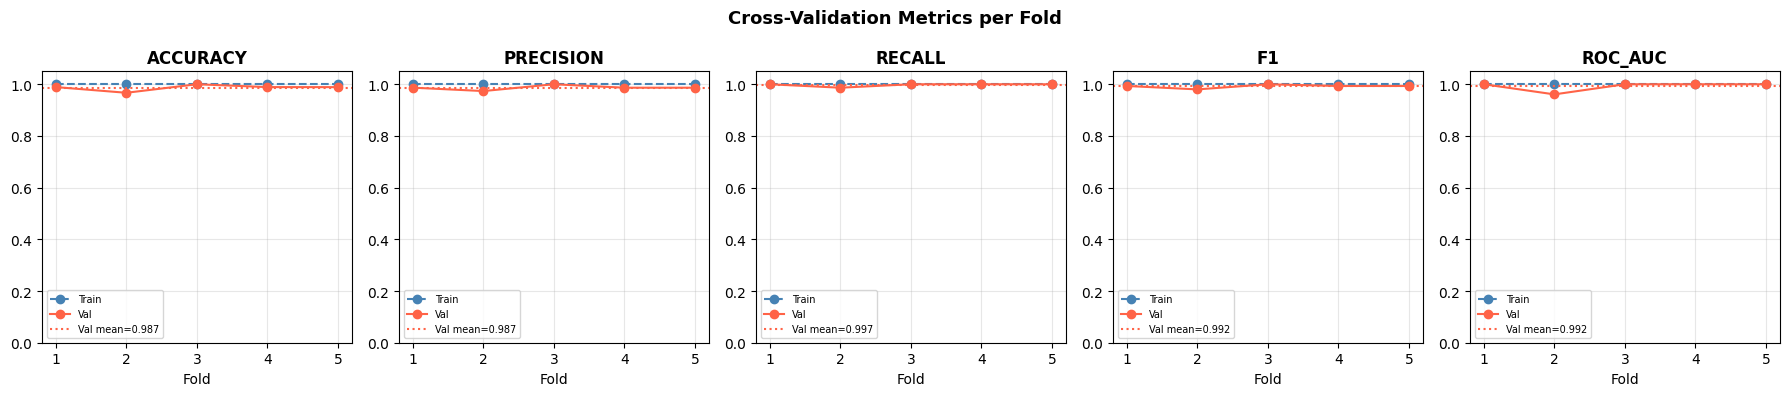

In [7]:
# Plot CV Metrics per Fold
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
fold_ids = np.arange(1, N_FOLDS + 1)

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 4))

for ax, metric in zip(axes, metrics_to_plot):
    train_scores = cv_results[f'train_{metric}']
    val_scores   = cv_results[f'test_{metric}']
    ax.plot(fold_ids, train_scores, 'o--', color='steelblue', label='Train')
    ax.plot(fold_ids, val_scores,   'o-',  color='tomato',    label='Val')
    ax.axhline(val_scores.mean(), color='tomato', linestyle=':', linewidth=1.5,
               label=f'Val mean={val_scores.mean():.3f}')
    ax.set_title(metric.upper(), fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Cross-Validation Metrics per Fold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Final Model (Train on Full Dataset)
pipeline.fit(X, y)
print('Final model trained on full dataset.')

y_pred       = pipeline.predict(X)
y_pred_proba = pipeline.predict_proba(X)[:, 1]

print(f'\nIn-sample accuracy : {accuracy_score(y, y_pred):.4f}')
print('(Use CV scores above as your real performance estimate)')

Final model trained on full dataset.

In-sample accuracy : 1.0000
(Use CV scores above as your real performance estimate)


=== Out-of-Fold Classification Report ===
              precision    recall  f1-score   support

    No-Drone       0.99      0.94      0.96        82
       Drone       0.99      1.00      0.99       372

    accuracy                           0.99       454
   macro avg       0.99      0.97      0.98       454
weighted avg       0.99      0.99      0.99       454



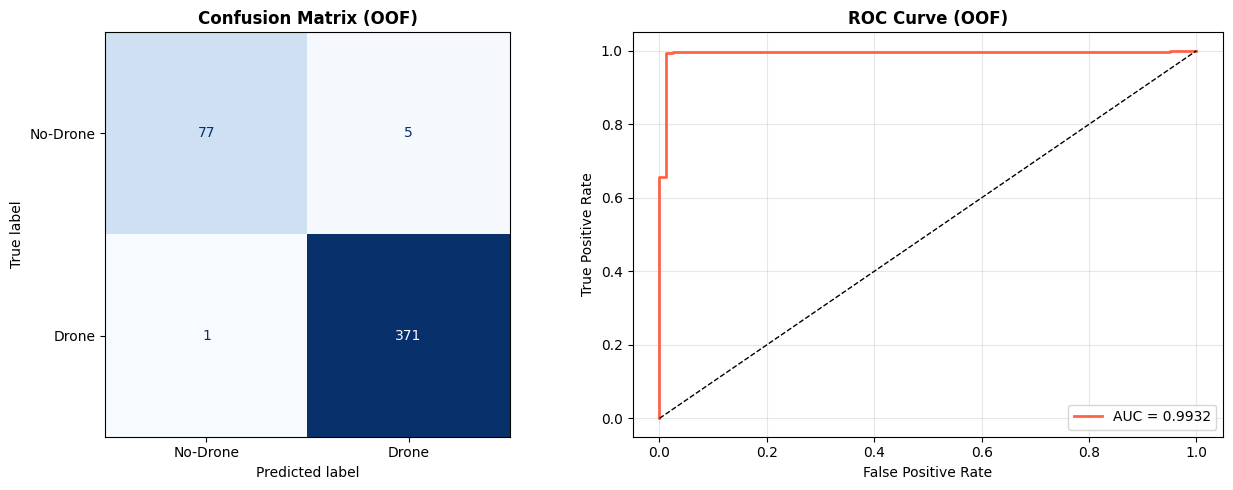

In [9]:
# OOF Confusion Matrix and ROC Curve
y_oof       = cross_val_predict(pipeline, X, y, cv=cv, method='predict')
y_oof_proba = cross_val_predict(pipeline, X, y, cv=cv, method='predict_proba')[:, 1]

print('=== Out-of-Fold Classification Report ===')
print(classification_report(y, y_oof, target_names=['No-Drone', 'Drone']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y, y_oof)
ConfusionMatrixDisplay(cm, display_labels=['No-Drone', 'Drone']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix (OOF)', fontweight='bold')

fpr, tpr, _ = roc_curve(y, y_oof_proba)
auc_score   = roc_auc_score(y, y_oof_proba)
axes[1].plot(fpr, tpr, color='tomato', lw=2, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (OOF)', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

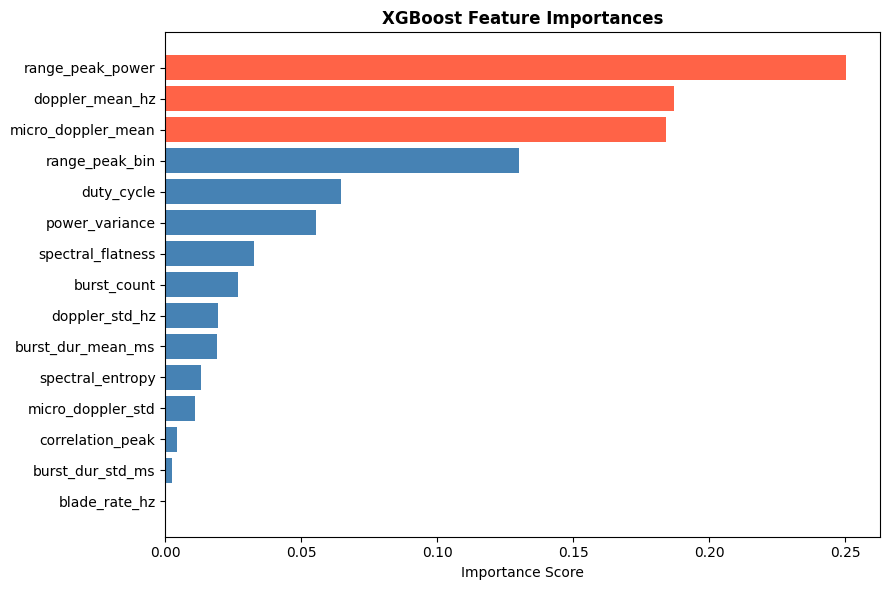


Top 5 most important features:
               feature  importance
14    range_peak_power    0.250335
11     doppler_mean_hz    0.187071
8   micro_doppler_mean    0.184082
13      range_peak_bin    0.129907
7           duty_cycle    0.064569


In [10]:
# Feature Importance
importances = pipeline.named_steps['clf'].feature_importances_
feat_imp_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(9, 6))
colors = ['tomato' if i >= len(feat_imp_df) - 3 else 'steelblue'
          for i in range(len(feat_imp_df))]
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(feat_imp_df.sort_values('importance', ascending=False).head())

In [ ]:
# Save Model
joblib.dump(pipeline, MODEL_OUT)
print(f'Model saved → {MODEL_OUT}')
print('Contains: StandardScaler + XGBClassifier')

Model saved → drone_xgb_model.pkl
Contains: StandardScaler + XGBClassifier


In [ ]:
# INFERENCE ON UNSEEN DATA

from scipy.signal import find_peaks
import os
from scipy.signal import find_peaks

# ── Set your path here ────────────────────────────────────
# For a single file:  INPUT_PATH = r"C:\path\to\file.npy"
# For a folder:       INPUT_PATH = r"C:\path\to\folder"
INPUT_PATH = r"C:\Users\RF-LAB\Desktop\Pipeline\New_Test_Data_Noise_processed"
# ─────────────────────────────────────────────────────────

fs           = 100e6
BURST_THRESH = 0.3
NPERSEG      = 1024
HOP          = 512
MAX_SAMPLES  = 5_000_000

def spectral_flatness(power_spec):
    ps = np.abs(power_spec) + 1e-12
    return float(np.exp(np.mean(np.log(ps))) / np.mean(ps))

def spectral_entropy(power_spec):
    ps = np.abs(power_spec) + 1e-12
    ps_norm = ps / np.sum(ps)
    return float(-np.sum(ps_norm * np.log2(ps_norm)))

def correlation_peak(z):
    seg = z[:1_000_000]; N = len(seg)
    Z = np.fft.fft(seg, n=2*N)
    acorr = np.fft.ifft(Z * np.conj(Z)).real[:N]
    acorr /= (acorr[0] + 1e-12)
    peaks, _ = find_peaks(acorr[1:], height=0.05)
    return float(acorr[peaks[0] + 1]) if len(peaks) > 0 else 0.0

def power_variance(z, window_size=1024):
    power = np.abs(z) ** 2
    n_blocks = len(power) // window_size
    if n_blocks == 0:
        return float(np.var(power))
    blocks = power[:n_blocks * window_size].reshape(n_blocks, window_size)
    return float(np.var(np.mean(blocks, axis=1)))

def burst_features(z, fs, threshold=BURST_THRESH):
    amplitude = np.abs(z)
    active = (amplitude > threshold * np.max(amplitude)).astype(np.int32)
    diff = np.diff(active)
    starts, ends = np.where(diff == 1)[0], np.where(diff == -1)[0]
    duty = float(np.mean(active.astype(np.float32)))
    if len(starts) == 0 or len(ends) == 0: return 0, 0.0, 0.0, duty
    if ends[0] < starts[0]: ends = ends[1:]
    if len(starts) > len(ends): starts = starts[:len(ends)]
    if len(starts) == 0: return 0, 0.0, 0.0, duty
    durations_ms = (ends - starts) / fs * 1000.0
    return int(len(durations_ms)), float(np.mean(durations_ms)), float(np.std(durations_ms)), duty

def micro_doppler(z, fs, nperseg=NPERSEG, hop=HOP):
    seg = z[:500_000]
    window = np.hanning(nperseg).astype(np.float32)
    n_steps = (len(seg) - nperseg) // hop + 1
    if n_steps <= 0: return 0.0, 0.0, 0.0
    energy = np.array([np.sum(np.abs(np.fft.fft(seg[i*hop:i*hop+nperseg] * window))) for i in range(n_steps)])
    freqs = np.fft.rfftfreq(len(energy), d=hop/fs)
    mask = (freqs >= 10) & (freqs <= 300)
    blade = float(freqs[mask][np.argmax(np.abs(np.fft.rfft(energy))[mask])]) if np.any(mask) else 0.0
    return float(np.mean(energy)), float(np.std(energy)), blade

def doppler_shift(z, fs):
    inst_freq = np.diff(np.unwrap(np.angle(z))) / (2.0 * np.pi) * fs
    return float(np.mean(inst_freq)), float(np.std(inst_freq))

def range_fft(z, nperseg=NPERSEG):
    n_seg = len(z) // nperseg
    if n_seg == 0: return 0.0, 0.0
    window = np.hanning(nperseg).astype(np.float32)
    avg = np.mean([np.abs(np.fft.fft(z[i*nperseg:(i+1)*nperseg] * window)) for i in range(n_seg)], axis=0)
    return float(np.argmax(avg)), float(avg[int(np.argmax(avg))])

def extract_features(filepath):
    data = np.load(filepath)
    if data.ndim == 2:
        I, Q = data[0].astype(np.float32), data[1].astype(np.float32)
    elif np.iscomplexobj(data):
        I, Q = data.real.astype(np.float32), data.imag.astype(np.float32)
    else:
        raise ValueError(f"Unexpected shape {data.shape}, dtype {data.dtype}")
    N = len(I)
    if N > MAX_SAMPLES:
        idx = np.linspace(0, N-1, MAX_SAMPLES, dtype=np.int64)
        I, Q = I[idx], Q[idx]
    z = I + 1j * Q
    power_spec = np.abs(np.fft.fft(z * np.hanning(len(z)).astype(np.float32))) ** 2
    sf  = spectral_flatness(power_spec)
    se  = spectral_entropy(power_spec)
    cp_ = correlation_peak(z)
    pv  = power_variance(z)
    bc, bd_mean, bd_std, dc = burst_features(z, fs)
    md_mean, md_std, blade  = micro_doppler(z, fs)
    dop_mean, dop_std       = doppler_shift(z, fs)
    r_bin, r_pwr            = range_fft(z)
    return [sf, se, cp_, pv, bc, bd_mean, bd_std, dc,
            md_mean, md_std, blade, dop_mean, dop_std, r_bin, r_pwr]

# ── Load the already-trained model ────────────────────────
loaded_pipeline = joblib.load(MODEL_OUT)
label_map = {0: 'No-Drone', 1: 'Drone'}

# ── Resolve single file or folder ─────────────────────────
if os.path.isfile(INPUT_PATH):
    npy_files = [INPUT_PATH]
elif os.path.isdir(INPUT_PATH):
    npy_files = sorted([
        os.path.join(INPUT_PATH, f)
        for f in os.listdir(INPUT_PATH) if f.endswith('.npy')
    ])
else:
    raise ValueError(f"INPUT_PATH does not exist: {INPUT_PATH}")

print(f"Found {len(npy_files)} file(s). Running inference...\n")
results = []

for fp in npy_files:
    fname = os.path.basename(fp)
    try:
        features    = extract_features(fp)
        pred        = loaded_pipeline.predict([features])[0]
        proba       = loaded_pipeline.predict_proba([features])[0]
        results.append({
            'file'         : fname,
            'prediction'   : label_map[pred],
            'prob_no_drone': round(proba[0], 4),
            'prob_drone'   : round(proba[1], 4),
        })
        print(f"  {'[DRONE]   ' if pred==1 else '[NO-DRONE]'}  {fname}  "
              f"(Drone={proba[1]:.4f}, No-Drone={proba[0]:.4f})")
    except Exception as e:
        print(f"  [ERROR]    {fname}  →  {e}")
        results.append({'file': fname, 'prediction': 'ERROR',
                        'prob_no_drone': None, 'prob_drone': None})

results_df = pd.DataFrame(results)
print(f"\n{'='*55}")
print(f"  Drone: {(results_df['prediction']=='Drone').sum()}  |  "
      f"No-Drone: {(results_df['prediction']=='No-Drone').sum()}  |  "
      f"Errors: {(results_df['prediction']=='ERROR').sum()}")
print(f"{'='*55}")
display(results_df)

results_df.to_csv("inference_results.csv", index=False)
print("\nSaved → inference_results.csv")


Found 4 file(s). Running inference...

  [NO-DRONE]  00000H_26_processed.npy  (Drone=0.0286, No-Drone=0.9714)
  [NO-DRONE]  00000L_13_processed.npy  (Drone=0.0127, No-Drone=0.9873)
  [NO-DRONE]  00000L_29_processed.npy  (Drone=0.0078, No-Drone=0.9922)
  [DRONE]     sunofdm_O2_mcs2_g0.0dB_att22dB_freq864.0MHz_4_processed.npy  (Drone=0.9985, No-Drone=0.0015)

  Drone: 1  |  No-Drone: 3  |  Errors: 0


,file,prediction,prob_no_drone,prob_drone
0,00000H_26_processed.npy,No-Drone,0.9714,0.0286
1,00000L_13_processed.npy,No-Drone,0.9873,0.0127
2,00000L_29_processed.npy,No-Drone,0.9922,0.0078
3,sunofdm_O2_mcs2_g0.0dB_att22dB_freq864.0MHz_4_...,Drone,0.0015,0.9985



Saved → inference_results.csv


In [ ]:
import os
import glob

# Find all no-drone processed files from DroneRF training set
TRAIN_DIR = r"C:\Users\RF-LAB\Desktop\Pipeline\Train_iq_preprocessed"

nodrone_files = []
for root, dirs, files in os.walk(TRAIN_DIR):
    for f in files:
        if f.startswith('00000') and f.endswith('_processed.npy'):
            nodrone_files.append(os.path.join(root, f))

print(f"Total no-drone files in training set: {len(nodrone_files)}")

Total no-drone files in training set: 82
